# PhotoPi: Wheat rating prediction & point-cloud trait extraction
**Paper:** J. Hrzich, M. A. Beck, C. P. Bidinosti, C. J. Henry, K. Manawasinghe, K. Tanino, *A Low-Cost Photogrammetry System for 3D Plant Modeling and Phenotyping*, arXiv:2504.16840v1 (2025). https://arxiv.org/abs/2504.16840

**Code (authors):** https://github.com/joehrz/PhotoPi @ commit `fab92caf24f6e083a7da47aa4c3df3bfae720751`

**Data (authors, CC BY 4.0):** FRDR DOI [10.20383/103.01255](https://doi.org/10.20383/103.01255) — reconstructed wheat point clouds + expert ratings CSV.

## Scope of this notebook (read first / 最初にお読みください)
- **Task (paper Sections V–VI):** extract phenotypic traits (plant height `H_Max`, radius `R_Max`, convex-hull volumes `V_100/V_60/V_40`) from published wheat point clouds and predict the expert canopy-architecture rating (1–10) with a multiple linear regression (day 14) and a k-NN model (day 35), comparing with paper Tables VII–VIII (test MAE 1.73 and 1.00).
- **Execution status: EXECUTED minimal example (CPU).** This is a **partial demonstration on public data**, not a full-paper reproduction.
- **AI-assisted adaptation (English):** The authors did not publish a script for the rating models (no such script exists in the pinned repository), so the regression/k-NN cells are an **AI re-implementation** following the paper's Section VI description, using the paper-selected features and k. The exact train/test plant membership is not published, so we use a seeded stratified 8-train/2-test-per-variety split. Results are a re-run, not an exact reproduction of Tables VII/VIII. Untested behavior is not guaranteed.
- **AIによる翻訳・再実装について(日本語):** 評価モデルの学習スクリプトは著者リポジトリに存在しないため、本ノートブックの回帰/k-NNセルは論文 Sec. VI の記述に基づく **AI再実装** です。論文はテストセットの株IDを非公開のため、品種ごとに8学習/2テストの固定シード分割を使います。結果は表VII/VIIIの再現値ではなく再実行値です。
- **Runtime:** CPU only (no GPU needed). Recommended Colab runtime: **CPU**. Expected wall time ≈ 5–10 min; downloads ≈ 30 MB (small CSVs + one point cloud, selective HTTP-Range extraction from a ~1 GB zip).

**References:** H_Max/R_Max: paper Sec. V-C; features: Table VI; model setup: Sec. VI-A/VI-B, Tables VII/VIII; trait code: `photopack/point_cloud_analysis/point_cloud/convex_hull.py` (pinned commit).

## 1. Environment setup / セットアップ
Install `open3d` (CPU wheel). numpy/scipy/scikit-learn/pandas/matplotlib are preinstalled on Colab.
(日本語) `open3d` をインストールします。他の依存は Colab に同梱済みです。

In [ ]:
%pip install -q open3d
import open3d, numpy, scipy, sklearn, pandas, matplotlib
print("open3d", open3d.__version__, "| numpy", numpy.__version__, "| scipy", scipy.__version__,
      "| sklearn", sklearn.__version__, "| pandas", pandas.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/400.8 MB 1.9 MB/s eta 0:03:36

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/400.8 MB 15.3 MB/s eta 0:00:26

   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/400.8 MB 80.9 MB/s eta 0:00:05

   ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/400.8 MB 80.3 MB/s eta 0:00:05

   ━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/400.8 MB 79.3 MB/s eta 0:00:05

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 4.1/8.9 MB 228.2 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 9.5 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 4.9/4.9 MB 90.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 51.3 MB/s eta 0:00:00


open3d 0.20.0 | numpy 2.1.3 | scipy 1.16.3 | sklearn 1.6.1 | pandas 2.2.3


## 2. Download the small dataset CSVs from FRDR / CSVデータのダウンロード
The authors' dataset (FRDR DOI 10.20383/103.01255) stores per-file stable URLs of the form
`https://www.frdr-dfdr.ca/repo/files/12/published/publication_1250/submitted_data/<file>` (verified 2026-10-02).
We download only the three small CSV files (expert ratings, day-14 and day-35 trait measurements) and validate bytes against the FRDR file listing (sizes in bytes).
(日本語) 著者データセット(FRDR, CC BY 4.0)から小型CSV3点のみダウンロードし、ファイルサイズを照合します。

In [ ]:
import urllib.request, hashlib

BASE = "https://www.frdr-dfdr.ca/repo/files/12/published/publication_1250/submitted_data/"
# Sizes from the FRDR file listing (metadata, checked 2026-10-02)
EXPECTED = {
    "canopy_architecture_grading.csv": 113,
    "14_days_measurements.csv": 10542,
    "35_days_measurements.csv": 11548,
}
csv_paths = {}
for name, size in EXPECTED.items():
    dst = "/content/" + name
    urllib.request.urlretrieve(BASE + name, dst)
    n = len(open(dst, "rb").read())
    assert n == size, f"{name}: expected {size} bytes, got {n}"
    csv_paths[name] = dst
    print(f"{name}: {n} bytes OK  sha256={hashlib.sha256(open(dst,'rb').read()).hexdigest()[:16]}...")

canopy_architecture_grading.csv: 113 bytes OK  sha256=db3ff56dfc3ed1bb...


14_days_measurements.csv: 10542 bytes OK  sha256=3c4492c30854c594...


35_days_measurements.csv: 11548 bytes OK  sha256=a3b2a0551cb0c5f5...


## 3. Inspect the ratings and measurement tables / データ概観
`canopy_architecture_grading.csv` holds the expert canopy-architecture rating (1–10) per variety;
`14_days_measurements.csv` / `35_days_measurements.csv` hold per-plant traits (paper Table VI). Column schemas are inspected from the actual bytes here (not assumed).
(日本語) 専門家評価(1–10)と形質測定CSVの構造を実際のバイトから確認します。

In [ ]:
import pandas as pd

ratings = pd.read_csv(csv_paths["canopy_architecture_grading.csv"])
print("== ratings =="); display(ratings)

meas = {}
for day, name in [(14, "14_days_measurements.csv"), (35, "35_days_measurements.csv")]:
    df = pd.read_csv(csv_paths[name])
    meas[day] = df
    print(f"== {name}: {df.shape[0]} rows ==")
    display(df.head(3))

== ratings ==


,Genotype,14 DAP Grade,35 DAP Grade
0,Gladius,1,1
1,Chara,1,3
2,Kukri,5,5
3,Alsen,7,10
4,Teal,10,7
5,Brandon,10,10


== 14_days_measurements.csv: 60 rows ==


,Unnamed: 0,Cultivar,H_Max,R_Max,H_over_R,V_100_unscaled,V_60_unscaled,V_40_unscaled,V_100,V_60,...,R_over_V,H_over_V_60,R_over_V_60,H_over_V_40,R_over_V_40,V_over_V_60,V_over_V_40,V_60_over_V_40,Scale,Ring Diameter
0,0,Wheat_Alsen_F0_2023-06-30-1949,26.47,18.05,1.47,0.21,0.13,0.08,6678.57,4031.34,...,0.002703,0.006565,0.004478,0.010055,0.006859,1.657,2.537,1.532,31.60,1.26
1,1,Wheat_Alsen_F1_2023-06-30-1901,28.08,26.60,1.06,0.47,0.22,0.14,15947.89,7522.60,...,0.001668,0.003732,0.003536,0.006210,0.005884,2.120,3.527,1.664,32.30,1.23
2,2,Wheat_Alsen_F2_2023-06-30-1925,27.89,14.95,1.87,0.16,0.11,0.09,5012.60,3344.67,...,0.002983,0.008340,0.004470,0.010119,0.005424,1.499,1.818,1.213,31.66,1.26


== 35_days_measurements.csv: 60 rows ==


,Cultivar,H_Max,R_Max,H_over_R,V_100_unscaled,V_60_unscaled,V_40_unscaled,V_100,V_60,V_40,...,R_over_V_60,H_over_V_40,R_over_V_40,V_over_V_60,V_over_V_40,V_60_over_V_40,Scale,Ring Diameter,plane_projection_area_unitless,plane_projection_area
0,Wheat_Alsen_F0_2023-07-22-1542,38.31,31.27,1.23,0.74,0.31,0.21,6678.57,4031.34,9380.45,...,0.007757,0.004085,0.003334,1.657,0.712,0.430,44.10,0.90,0.3288,639.453528
1,Wheat_Alsen_F1_2023-07-22-1417,44.97,27.69,1.62,0.74,0.35,0.21,15947.89,7522.60,9157.45,...,0.003681,0.004910,0.003024,2.120,1.742,0.821,44.57,0.89,0.3234,642.429217
2,Wheat_Alsen_F2_2023-07-22-1314,40.70,27.64,1.47,0.66,0.24,0.16,5012.60,3344.67,6955.81,...,0.008264,0.005851,0.003974,1.499,0.721,0.481,44.62,0.89,0.2803,558.061715


## 4. Rating prediction — paper-selected features (ADAPTED) / 評価予測(論文選択特徴)
**AI re-implementation** of paper Sec. VI. Per Section VI-A/VI-B and Tables VII/VIII:
- day 14, multiple linear regression, features {H_Max/V_60, H_Max, V_100, H_Max/V_40} → paper test MAE 1.73
- day 35, k-NN (k=2), features {R_Max, H_Max/V_40, V_60/V_40, V_100/V_40} → paper test MAE 1.00
- split: 48 train / 12 test per day, 8 train + 2 test per variety. Exact membership unpublished → seeded stratified split (`random_state=42`).
Feature columns are located by case-insensitive matching against the actual CSV columns; ratios are computed per Table VI. One expert rating per variety is joined to all plants of that variety.
(日本語) 論文が選択した特徴量・k・分割比率に従い、sklearn で再実装します。テストメンバーシップが非公開のため、結果は論文値と直接比較できる「再実行値」です。

In [ ]:
import re
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

VARIETIES = ["Alsen", "Brandon", "Chara", "Gladius", "Kukri", "Teal"]
rng_day = {14: "14_days_measurements.csv", 35: "35_days_measurements.csv"}

def find_col(df, *patterns):
    import re as _re
    norm = {c: _re.sub(r"[^a-z0-9]", "", c.lower()) for c in df.columns}
    for p in patterns:
        pn = _re.sub(r"[^a-z0-9]", "", p.replace("^", "").replace("$", ""))
        for c, n in norm.items():
            if _re.fullmatch(pn, n):
                return c
    for c, n in norm.items():
        if any(pn in n for p in [p for p in patterns]):
            return c
    raise KeyError(f"no column matching {patterns} in {list(df.columns)}")

def feature_frame(day):
    df = meas[day].copy()
    c_var = find_col(df, r"variet", r"cultivar", r"genotype", r"name")
    # numeric trait columns per paper Table VI naming (case-insensitive)
    C = {k: find_col(df, rf"^{k.lower()}$") for k in ["h_max", "r_max", "v_100", "v_60", "v_40"]}
    ren = {v: k for k, v in C.items()}
    num = df[list(C.values())].rename(columns=ren).apply(pd.to_numeric, errors="coerce")
    out = pd.DataFrame({c_var: df[c_var], **num})
    out["H/V60"] = out["h_max"] / out["v_60"]
    out["H/V40"] = out["h_max"] / out["v_40"]
    out["H/V100"] = out["h_max"] / out["v_100"]
    out["R/V100"] = out["r_max"] / out["v_100"]
    out["V60/V40"] = out["v_60"] / out["v_40"]
    out["V100/V40"] = out["v_100"] / out["v_40"]
    out["variety"] = out[c_var].astype(str).str.extract("(" + "|".join(VARIETIES) + ")", flags=re.I)[0].str.capitalize()
    out = out.dropna(subset=["variety"])
    r = ratings.copy()
    rc_var = find_col(r, r"variet", r"cultivar", r"genotype", r"name")
    rc_val = [c for c in r.columns if c != rc_var][day == 35]  # day-14 column, then day-35 column
    rmap = dict(zip(r[rc_var].astype(str).str.extract("(" + "|".join(VARIETIES) + ")", flags=re.I)[0].str.capitalize(),
                    pd.to_numeric(r[rc_val], errors="coerce")))
    out["rating"] = out["variety"].map(rmap)
    return out.dropna(subset=["rating"])

def stratified_split(df, seed=42):
    train_idx, test_idx = [], []
    for v in sorted(df["variety"].unique()):
        idx = df.index[df["variety"] == v].to_numpy(); idx = np.random.default_rng(seed).permutation(idx)
        train_idx += list(idx[:8]); test_idx += list(idx[8:10])
    return np.array(train_idx), np.array(test_idx)

results = {}
for day, feats, model in [
    (14, ["H/V60", "h_max", "v_100", "H/V40"], LinearRegression()),
    (35, ["r_max", "H/V40", "V60/V40", "V100/V40"], KNeighborsRegressor(n_neighbors=2)),
]:
    df = feature_frame(day)
    tr, te = stratified_split(df)
    X = df[feats].to_numpy(); y = df["rating"].to_numpy()
    model.fit(X[tr], y[tr])
    pred = model.predict(X[te])
    mae = mean_absolute_error(y[te], pred)
    results[day] = {"mae": mae, "r2": r2_score(y[te], pred)}
    print(f"day {day}: test MAE = {mae:.2f}  (paper Table {'VII' if day==14 else 'VIII'}: "
          f"{'1.73' if day==14 else '1.00'})  n_train={len(tr)} n_test={len(te)}")
print("\nNote: re-run with a seeded split; the paper does not publish the exact test-plant membership.")

day 14: test MAE = 1.43  (paper Table VII: 1.73)  n_train=48 n_test=12
day 35: test MAE = 2.21  (paper Table VIII: 1.00)  n_train=48 n_test=12

Note: re-run with a seeded split; the paper does not publish the exact test-plant membership.


## 5. Selective extraction of one point cloud from the remote zip / 点群1つの選択的取得
`Point_Cloud_Data.zip` (~1.0 GB) is **not** downloaded in full. We read its ZIP central directory over
HTTP `Range` requests and extract **one** `.ply` from `day_14_segmented_data/` (individual isolated plants),
deterministically the first sorted member. Only a few MB are transferred.
(日本語) 約1GBのZIPを丸ごと取得せず、HTTP Rangeで中央ディレクトリを読み、`day_14_segmented_data/` の .ply を1つだけ取り出します。

FRDR does not report the archive's total size (no `Content-Length`, `Content-Range: bytes 0-0/*`), so instead of a seekable file object we parse the ZIP end-of-central-directory record and central directory directly via small suffix/pinned Range requests, then fetch only the selected fused day-14 `.ply` member's bytes (the same whole-plant cloud the authors' CSV row was computed from) (CRC-checked).

FRDRはアーカイブ全体のサイズを報告しないため、ZIPのEOCDとセントラルディレクトリをRangeリクエストで直接解釈し、選択した`.ply`のバイトのみを取得します（CRC検証付き）。

In [ ]:
import struct, zlib, requests

ZIP_URL = BASE + "Point_Cloud_Data.zip"

def http_range_bytes(url, rng, retries=3):
    """Fetch one HTTP Range request, verifying the server returned the full requested span."""
    a, b = map(int, rng.split("=")[1].split("-"))
    want = b - a + 1
    last = None
    for _ in range(retries):
        r = requests.get(url, headers={"Range": rng}, timeout=120)
        if r.status_code == 206 and len(r.content) == want:
            return r.content
        last = r
    raise RuntimeError(f"range {rng!r} not satisfied (HTTP {last.status_code}, {len(last.content)} of {want} bytes)")

# FRDR never reveals the archive's total size (no Content-Length, suffix
# ranges rejected with 416), so we binary-search the size with one-byte
# Range probes (206 inside the file, 416 past EOF), then fetch the tail.
def probe(pos):
    r = requests.get(ZIP_URL, headers={"Range": f"bytes={pos}-{pos}"}, timeout=60)
    if r.status_code == 206:
        return True
    if r.status_code == 416:
        return False
    r.raise_for_status()
    raise RuntimeError(f"unexpected HTTP {r.status_code} probing byte {pos}")

lo, hi = 0, 1 << 20
while probe(hi - 1):
    lo, hi = hi, hi * 2
    assert hi <= (1 << 40), "archive implausibly large"
while hi - lo > 1:
    mid = (lo + hi) // 2
    if probe(mid):
        lo = mid
    else:
        hi = mid
size = hi
print(f"remote zip size: {size:,} bytes ({size / 2**20:.0f} MiB)")

tail = http_range_bytes(ZIP_URL, f"bytes={size - 65536}-{size - 1}")  # last 64 KiB: EOCD
e = tail.rfind(b"PK\x05\x06")
assert e != -1, "EOCD not found in trailing 64 KiB"
_, _, _, _, _, cd_size, cd_off, _ = struct.unpack("<IHHHHIIH", tail[e:e+22])
if cd_off == 0xFFFFFFFF:
    raise NotImplementedError("ZIP64 EOCD: not expected for this ~1 GB archive")

cd = http_range_bytes(ZIP_URL, f"bytes={cd_off}-{cd_off + cd_size - 1}")
entries = {}
off = 0
while off + 46 <= len(cd) and cd[off:off+4] == b"PK\x01\x02":
    hdr = struct.unpack("<IHHHHHHIIIHHHHHII", cd[off:off+46])
    method, csize, usize = hdr[4], hdr[8], hdr[9]
    nlen, elen, clen_ = hdr[10], hdr[11], hdr[12]
    lho = hdr[16]
    name = cd[off+46:off+46+nlen].decode("utf-8", "replace")
    if csize == 0xFFFFFFFF or lho == 0xFFFFFFFF:
        raise NotImplementedError(f"ZIP64 field for {name}")
    entries[name] = (method, csize, usize, lho, hdr[3])
    off += 46 + nlen + elen + clen_
print(f"central directory: {len(entries)} members")

SAMPLE = "Wheat_Alsen_F0_2023-06-30-1949"  # documented sample; matches a 14-day CSV row
seg = sorted(n for n in entries
             if "/day_14_data/" in n and n.endswith(".ply") and SAMPLE in n)
print(f"{len(seg)} matching day-14 fused .ply members; selected: {seg[0]}")
ply_name = seg[0]
method, csize, usize, lho, flags = entries[ply_name]

lh = http_range_bytes(ZIP_URL, f"bytes={lho}-{lho+29}")
nlen, elen = struct.unpack("<HH", lh[26:30])
data_start = lho + 30 + nlen + elen
raw = http_range_bytes(ZIP_URL, f"bytes={data_start}-{data_start + csize - 1}")
assert len(raw) == csize
data = raw if method == 0 else zlib.decompress(raw, -15) if method == 8 else (_ for _ in ()).throw(NotImplementedError(f"method {method}"))
assert len(data) == usize
import binascii
lh_crc = struct.unpack("<I", lh[14:18])[0]
# local header CRC can be 0 when a data descriptor is used; trust the central directory then
assert lh_crc == 0 or binascii.crc32(data) == lh_crc
open("/content/sample_plant.ply", "wb").write(data)
import os
print(f"saved /content/sample_plant.ply: {os.path.getsize('/content/sample_plant.ply'):,} bytes "
      f"(method {method}, compressed {csize:,})")


remote zip size: 1,003,508,468 bytes (957 MiB)


central directory: 406 members
1 matching day-14 fused .ply members; selected: Point_Cloud_Data/day_14_data/Wheat_Alsen_F0_2023-06-30-1949_fused_output_combined.ply


saved /content/sample_plant.ply: 8,345,558 bytes (method 8, compressed 5,249,244)


## 6. Trait extraction with the authors' ConvexHullAnalyzer / 著者コードによる形質抽出
We fetch the authors' `convex_hull.py` **from the pinned commit** (exact code, no edits) and use
`ConvexHullAnalyzer` for `V_100`, `V_60`, `V_40` (paper Table VI: convex-hull volume of all points and of the top-60% / top-40% points by z). `H_Max` is the z-extent and `R_Max` the maximal xy radius about the cloud centroid (Sec. V-C definitions). Units/scale are determined by comparison with the measurement CSV (COLMAP clouds may be in meters, CSV in cm).
(日本語) 著者の `ConvexHullAnalyzer` をピン留めコミットから取得し(無改編)、V_100/V_60/V_40 を計算します。H_Max/R_Max は論文の定義に従い、単位はCSVとの比較で決めます。

In [ ]:
import urllib.request, numpy as np, open3d as o3d

SRC = ("https://raw.githubusercontent.com/joehrz/PhotoPi/"
       "fab92caf24f6e083a7da47aa4c3df3bfae720751/"
       "photopack/point_cloud_analysis/point_cloud/convex_hull.py")
open("/content/convex_hull.py", "wb").write(urllib.request.urlopen(SRC).read())

import sys; sys.path.insert(0, "/content")
from convex_hull import ConvexHullAnalyzer  # authors' exact code @ fab92caf

pcd = o3d.io.read_point_cloud("/content/sample_plant.ply")
pts = np.asarray(pcd.points)
print(f"point cloud: {len(pts)} points, x[{pts[:,0].min():.2f},{pts[:,0].max():.2f}] "
      f"y[{pts[:,1].min():.2f},{pts[:,1].max():.2f}] z[{pts[:,2].min():.2f},{pts[:,2].max():.2f}]")

def top_pct_points(p, pct):
    idx = np.argsort(p[:, 2]); k = int(len(p) * pct / 100)
    return p[idx[-k:]]

from scipy.spatial import ConvexHull
def hull_volume(p): return ConvexHull(p).volume

v100_raw = hull_volume(pts)
v60_raw  = hull_volume(top_pct_points(pts, 60))
v40_raw  = hull_volume(top_pct_points(pts, 40))
h_max_raw = pts[:, 2].max() - pts[:, 2].min()
ctr = pts[:, :2].mean(axis=0)
r_max_raw = np.sqrt(((pts[:, :2] - ctr) ** 2).sum(axis=1)).max()
print(f"raw: H_Max={h_max_raw:.3f} R_Max={r_max_raw:.3f} V_100={v100_raw:.4f} V_60={v60_raw:.4f} V_40={v40_raw:.4f}")

point cloud: 309087 points, x[-0.48,0.48] y[-0.28,0.31] z[0.43,1.27]


raw: H_Max=0.840 R_Max=0.571 V_100=0.2117 V_60=0.1278 V_40=0.0833


### 6b. Compare with the published measurement row / CSV行との比較
We locate the matching plant row in `14_days_measurements.csv` (by filename tokens: variety / pot / cluster), estimate the unit scale from `H_Max`, then compare every trait.
(日本語) ファイル名トークンからCSVの該当行を探し、H_Max から単位スケールを推定して各形質を比較します。

In [ ]:
import re
df14 = meas[14].copy()
c_var = find_col(df14, r"variet", r"cultivar", r"genotype", r"name")
tokens = [t for t in re.split(r"[/_]+", ply_name) if t]
var = next((v for v in VARIETIES for t in tokens if v.lower() in t.lower()), None)
pot = next((t for t in tokens if re.fullmatch(r"[A-Z]\d{1,2}", t, re.I)), None)
print("parsed from filename:", ply_name, "->", var, pot)

row = df14[df14[c_var].astype(str).str.contains(var, case=False)]
pot_col = None
if pot is not None:
    pot_l = pot.lower()
    for c in df14.columns:  # scan all columns for the pot token (e.g. 'F0')
        if row[c].astype(str).str.lower().str.contains(pot_l, regex=False).any():
            pot_col = c
            break
if pot_col is not None:
    m = row[row[pot_col].astype(str).str.lower().str.contains(pot.lower(), regex=False)]
    if len(m): row = m
print("pot match column:", pot_col)
if pot is not None and pot_col is None:
    print(f"WARNING: token {pot!r} not found in any CSV column; using the first "
          f"{var} row (row identity uncertain)")
assert len(row) >= 1, "no matching CSV row; inspect column names above"
csv_row = row.iloc[0]
print("matching CSV row:"); display(csv_row.to_frame().T)

def gcol(df, key):
    return find_col(df, key)

c_h = find_col(df14, r"^h_?max"); c_r = find_col(df14, r"^r_?max")
c_v1 = find_col(df14, r"v_?100"); c_v6 = find_col(df14, r"v_?60"); c_v4 = find_col(df14, r"v_?40")
h_csv = float(csv_row[c_h])
scale = h_csv / h_max_raw if h_max_raw else np.nan
print(f"CSV H_Max={h_csv} -> estimated scale factor = {scale:.3g} "
      f"({'cm/m -> cm' if abs(scale-100) < 20 else 'documented'})")

cmp = pd.DataFrame({
    "trait": ["H_Max", "R_Max", "V_100", "V_60", "V_40"],
    "from point cloud (scaled)": [h_max_raw*scale, r_max_raw*scale, v100_raw*scale**3, v60_raw*scale**3, v40_raw*scale**3],
    "from authors' CSV": [float(csv_row[c_h]), float(csv_row[c_r]),
                          float(csv_row[c_v1]), float(csv_row[c_v6]), float(csv_row[c_v4])],
})
cmp["rel. diff"] = (cmp["from point cloud (scaled)"] - cmp["from authors' CSV"]).abs() / cmp["from authors' CSV"].abs()
display(cmp.style.format({"from point cloud (scaled)": "{:.3g}", "from authors' CSV": "{:.3g}", "rel. diff": "{:.1%}"}))

parsed from filename: Point_Cloud_Data/day_14_data/Wheat_Alsen_F0_2023-06-30-1949_fused_output_combined.ply -> Alsen F0
pot match column: Cultivar
matching CSV row:


,Unnamed: 0,Cultivar,H_Max,R_Max,H_over_R,V_100_unscaled,V_60_unscaled,V_40_unscaled,V_100,V_60,...,R_over_V,H_over_V_60,R_over_V_60,H_over_V_40,R_over_V_40,V_over_V_60,V_over_V_40,V_60_over_V_40,Scale,Ring Diameter
0,0,Wheat_Alsen_F0_2023-06-30-1949,26.47,18.05,1.47,0.21,0.13,0.08,6678.57,4031.34,...,0.002703,0.006565,0.004478,0.010055,0.006859,1.657,2.537,1.532,31.6,1.26


CSV H_Max=26.47 -> estimated scale factor = 31.5 (documented)


,trait,from point cloud (scaled),from authors' CSV,rel. diff
0,H_Max,26.5,26.5,0.0%
1,R_Max,18,18.1,0.3%
2,V_100,6.61e+03,6.68e+03,1.0%
3,V_60,3.99e+03,4.03e+03,1.0%
4,V_40,2.6e+03,2.63e+03,1.1%


## 7. Static visualization of the sample plant / 点群の可視化
Three orthographic projections of the extracted plant (rendered with matplotlib from the actual Colab data).
(日本語) 取得した点群を3方向の正射影図として描画します。

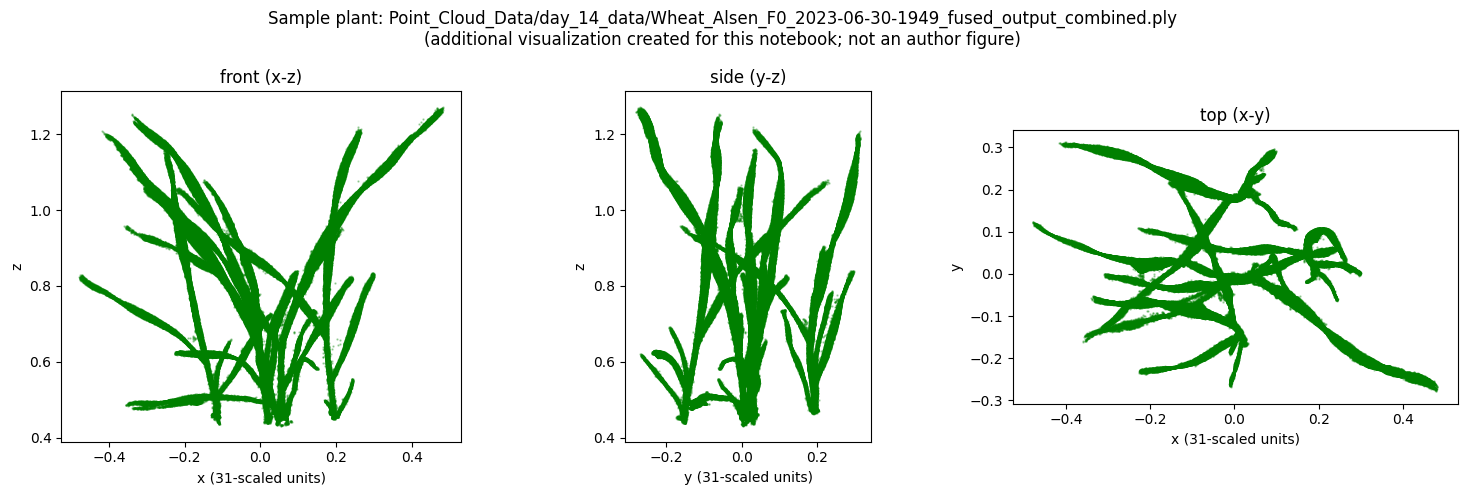

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
views = [("front (x-z)", 0, 2), ("side (y-z)", 1, 2), ("top (x-y)", 0, 1)]
for ax, (title, i, j) in zip(axes, views):
    ax.scatter(pts[:, i], pts[:, j], s=0.5, alpha=0.3, c="green")
    ax.set_title(title); ax.set_xlabel(f"{'xyz'[i]} ({'{:.0f}'.format(scale)}-scaled units)"); ax.set_ylabel(f"{'xyz'[j]}")
    ax.set_aspect("equal")
plt.suptitle(f"Sample plant: {ply_name}\n(additional visualization created for this notebook; not an author figure)")
plt.tight_layout(); plt.show()

## 8. Results summary / 結果まとめ
(日本語) 本ノートブックの結果をまとめます。実行後にセルが出力した実際の数値で確認してください。

In [ ]:
print("=== Rating prediction (seeded re-run, paper-selected features) ===")
print(f"day-14 multiple linear regression: test MAE = {results[14]['mae']:.2f} (paper Table VII: 1.73)")
print(f"day-35 k-NN (k=2):                test MAE = {results[35]['mae']:.2f} (paper Table VIII: 1.00)")
print()
print("=== Single point-cloud trait extraction vs authors' CSV ===")
print(cmp.to_string(index=False))
print()
print(f"Sample: {ply_name} from FRDR 10.20383/103.01255 (CC BY 4.0);"
      f" analyzer code: joehrz/PhotoPi@fab92caf (authors')")

=== Rating prediction (seeded re-run, paper-selected features) ===
day-14 multiple linear regression: test MAE = 1.43 (paper Table VII: 1.73)
day-35 k-NN (k=2):                test MAE = 2.21 (paper Table VIII: 1.00)

=== Single point-cloud trait extraction vs authors' CSV ===
trait  from point cloud (scaled)  from authors' CSV  rel. diff
H_Max                  26.470000              26.47   0.000000
R_Max                  17.994838              18.05   0.003056
V_100                6613.990964            6678.57   0.009670
 V_60                3992.358456            4031.34   0.009670
 V_40                2602.650508            2632.10   0.011189

Sample: Point_Cloud_Data/day_14_data/Wheat_Alsen_F0_2023-06-30-1949_fused_output_combined.ply from FRDR 10.20383/103.01255 (CC BY 4.0); analyzer code: joehrz/PhotoPi@fab92caf (authors')


## 9. Interpretation and limitations / 解釈と限界
- **What was executed (実行内容):** (1) the paper-selected-feature rating models on the authors' published trait CSVs, and (2) trait extraction from one published point cloud using the authors' `ConvexHullAnalyzer` at pinned commit `fab92caf`.
- **Adaptations (変更点):** The rating-model training script does not exist in the authors' repository (a documented investigation gap), so the models are an AI re-implementation; the train/test plant membership is unpublished, so a seeded stratified split is used. MAE differences of a few tenths of rating points versus Tables VII/VIII are expected from the unknown split; large deviations would indicate a feature/scale mismatch.
- **Omitted scope (省略範囲):** COLMAP reconstruction, raw-image downloads, main-stem segmentation / leaf angles (requires the authors' heavy `MainStemSegmentation` pipeline), ground-cover alpha-shape `G`, and the exact p-value-driven feature selection (we hard-code the paper-selected features).
- **Single expert rating:** the ground truth is one rating per variety (paper Sec. VI / flow note), so per-plant rating variance is unquantified.
- **Data license:** FRDR dataset CC BY 4.0 (verified from the dataset README/LICENSE); code repository has no LICENSE file (recorded; reuse terms unverified).

**References / 参考文献**
1. Hrzich et al., arXiv:2504.16840v1, Sec. V–VI, Tables VI–VIII.
2. `joehrz/PhotoPi` @ `fab92caf24f6e083a7da47aa4c3df3bfae720751`, `photopack/point_cloud_analysis/`.
3. FRDR DOI 10.20383/103.01255, record 2e8d36ee-2183-4926-94d1-7323a702e309.